В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

Area under ROC score on Training dataset: 0.88%


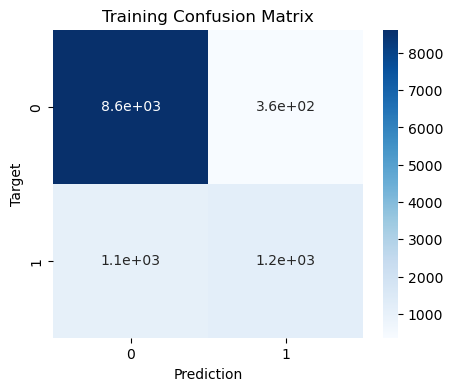

Area under ROC score on Validation dataset: 0.88%


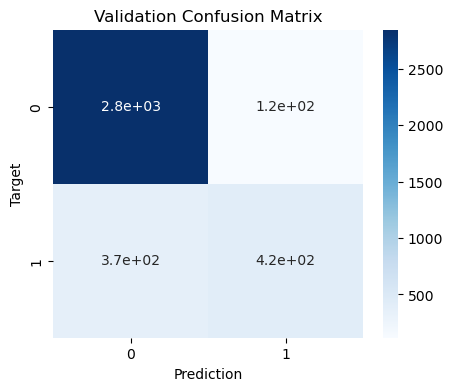

['logistic_regression_pipeline.joblib']

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
train_df = pd.read_csv("train.csv", index_col=0)
test_data = pd.read_csv("test.csv")

train_data, val_data = train_test_split(
    train_df,
    test_size=0.25,
    random_state=42
)

# Створюємо трен. і вал. набори
input_cols = [
    'CreditScore',
    'Geography',
    'Gender',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember',
    'EstimatedSalary'
]

target_col = 'Exited'
train_inputs = train_data[input_cols].copy()
train_targets = train_data[target_col].copy()
val_inputs = val_data[input_cols].copy()
val_targets = val_data[target_col].copy()
test_inputs = test_data[input_cols].copy()

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    probabilities = model_pipeline.predict_proba(inputs)[:, 1]
    roc_auc = roc_auc_score(targets, probabilities)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    confusion_matrix_ = confusion_matrix(targets, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(
    model_pipeline,
    train_inputs,
    train_targets,
    'Training'
)
val_preds = predict_and_plot(
    model_pipeline,
    val_inputs,
    val_targets,
    'Validation'
)

# Зберігаємо модель для подальшого використання
joblib.dump(
    model_pipeline,
    'logistic_regression_pipeline.joblib'
)

**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Area under ROC score on Polynomial Training dataset: 0.91%


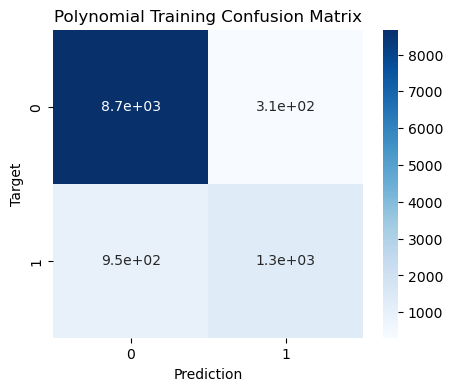

Area under ROC score on Polynomial Validation dataset: 0.91%


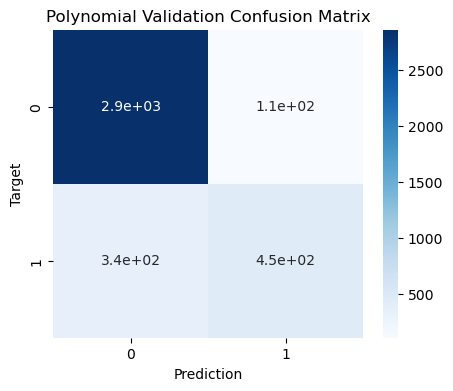

In [2]:
from sklearn.preprocessing import PolynomialFeatures

numeric_transformer_poly = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('polynomial', PolynomialFeatures(
        degree=2,
        include_bias=False
    )),
    ('scaler', MinMaxScaler())
])


preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)


model_pipeline_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('classifier', LogisticRegression(
        solver='liblinear',
        max_iter=1000,
        random_state=42
    ))
])


model_pipeline_poly.fit(
    train_inputs,
    train_targets
)


train_preds_poly = predict_and_plot(
    model_pipeline_poly,
    train_inputs,
    train_targets,
    'Polynomial Training'
)


val_preds_poly = predict_and_plot(
    model_pipeline_poly,
    val_inputs,
    val_targets,
    'Polynomial Validation'
)

Модель показала однакову якість на тренувальному та валідаційному наборах (ROC-AUC ≈ 0.91), тому ознак overfitting чи underfitting не спостерігається. Модель добре генералізує.

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score on Polynomial Degree 4 Training dataset: 0.93%


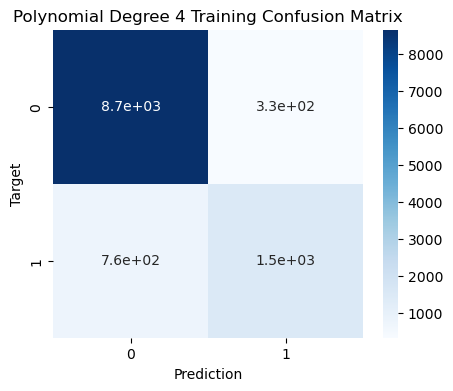

Area under ROC score on Polynomial Degree 4 Validation dataset: 0.92%


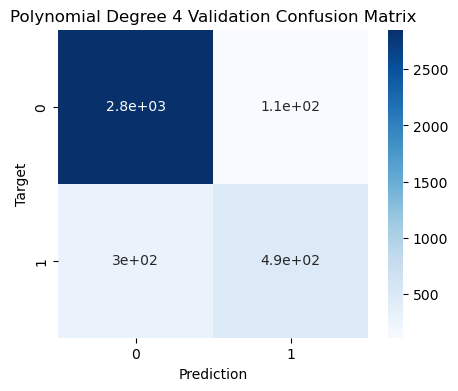

In [3]:
numeric_transformer_poly4 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('polynomial', PolynomialFeatures(
        degree=4,
        include_bias=False
    )),
    ('scaler', MinMaxScaler())
])

preprocessor_poly4 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly4, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

model_pipeline_poly4 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly4),
    ('classifier', LogisticRegression(
        solver='liblinear',
        max_iter=1000,
        random_state=42
    ))
])

model_pipeline_poly4.fit(
    train_inputs,
    train_targets
)

train_preds_poly4 = predict_and_plot(
    model_pipeline_poly4,
    train_inputs,
    train_targets,
    'Polynomial Degree 4 Training'
)

val_preds_poly4 = predict_and_plot(
    model_pipeline_poly4,
    val_inputs,
    val_targets,
    'Polynomial Degree 4 Validation'
)

Модель з поліноміальними ознаками 4-го степеня показала кращий результат, ніж модель зі степенем 2. Ознак overfitting або underfitting не спостерігається, оскільки результати на тренувальному та валідаційному наборах дуже близькі. Модель добре генералізує. Я використаю її для submission на Kaggle.

In [4]:
test_probs = model_pipeline_poly4.predict_proba(test_inputs)[:, 1]

submission = pd.DataFrame({
    'id': test_data['id'],
    'Exited': test_probs
})

submission.to_csv('submission.csv', index=False)

submission.head()

,id,Exited
0,15000,0.086207
1,15001,0.025210
2,15002,0.078582
3,15003,0.377911
4,15004,0.030329


**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [5]:
df = pd.read_csv('regression_data.csv')

In [6]:
X = df.drop(columns='target')
y = df['target']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
from sklearn.linear_model import LinearRegression

model = Pipeline(steps=[
    ('polynomial', PolynomialFeatures(
        degree=5,
        include_bias=False
    )),
    ('scaler', MinMaxScaler()),
    ('regression', LinearRegression())
])

In [9]:
model.fit(X_train, y_train)

,steps,"[('polynomial', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,5
,interaction_only,False
,include_bias,False
,order,'C'
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [10]:
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

In [11]:
from sklearn.metrics import r2_score, mean_squared_error

train_r2 = r2_score(y_train, train_predictions)

train_rmse = np.sqrt(
    mean_squared_error(y_train, train_predictions)
)

In [12]:
test_r2 = r2_score(y_test, test_predictions)

test_rmse = np.sqrt(
    mean_squared_error(y_test, test_predictions)
)

In [13]:
print(f'Train R^2: {train_r2:.4f}')
print(f'Train RMSE: {train_rmse:.4f}')

print(f'Test R^2: {test_r2:.4f}')
print(f'Test RMSE: {test_rmse:.4f}')

Train R^2: 1.0000
Train RMSE: 0.0000
Test R^2: 0.9345
Test RMSE: 12.3633


Модель показала хорошу якість на тестовому наборі, але ідеальний результат на тренувальному наборі свідчить про перенавчання. Тому модель добре прогнозує, але генералізує не ідеально.

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [14]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet

In [15]:
lasso_model = Pipeline(steps=[
    ('polynomial', PolynomialFeatures(degree=20, include_bias=False)),
    ('scaler', MinMaxScaler()),
    ('regression', Lasso(alpha=0.1, max_iter=10000))
])

lasso_model.fit(X_train, y_train)

,steps,"[('polynomial', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,20
,interaction_only,False
,include_bias,False
,order,'C'
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [16]:
ridge_model = Pipeline(steps=[
    ('polynomial', PolynomialFeatures(degree=20, include_bias=False)),
    ('scaler', MinMaxScaler()),
    ('regression', Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

,steps,"[('polynomial', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,20
,interaction_only,False
,include_bias,False
,order,'C'
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [17]:
elastic_model = Pipeline(steps=[
    ('polynomial', PolynomialFeatures(degree=20, include_bias=False)),
    ('scaler', MinMaxScaler()),
    ('regression', ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000))
])

elastic_model.fit(X_train, y_train)

,steps,"[('polynomial', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,20
,interaction_only,False
,include_bias,False
,order,'C'
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [18]:
def evaluate(model, X_train, X_test, y_train, y_test, name):

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    print(name)
    print(f"Train R^2: {train_r2:.4f}")
    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test R^2: {test_r2:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print("-" * 30)

In [19]:
evaluate(lasso_model, X_train, X_test, y_train, y_test, "Lasso")

evaluate(ridge_model, X_train, X_test, y_train, y_test, "Ridge")

evaluate(elastic_model, X_train, X_test, y_train, y_test, "ElasticNet")

Lasso
Train R^2: 0.9993
Train RMSE: 1.1986
Test R^2: 0.9996
Test RMSE: 1.0046
------------------------------
Ridge
Train R^2: 0.9620
Train RMSE: 8.5978
Test R^2: -1.5125
Test RMSE: 76.5627
------------------------------
ElasticNet
Train R^2: 0.8184
Train RMSE: 18.8100
Test R^2: -5.6896
Test RMSE: 124.9292
------------------------------


Найкраще генералізує Lasso, оскільки має дуже високий показник R^2 = 0.9996 на тестовому наборі та низький RMSE = 1.0046. Це означає, що модель добре прогнозує нові дані. Ймовірно, Lasso автоматично відкинув зайві поліноміальні ознаки 20-го степеня, що допомогло уникнути перенавчання. Моделі Ridge та ElasticNet показали значно гірші результати, тому для цих даних вони виявилися менш придатними.